# 🏠 House Price Prediction — King County

End-to-end analytics notebook using the King County Housing dataset.  
**Sections:**
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Preprocessing
4. Model Training & Evaluation (RandomForest + GradientBoosting)
5. Model Persistence

In [9]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Section 1 — Data Loading & Inspection

In [10]:
# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
import pathlib

# Resolve Housing.csv relative to this notebook file — works regardless of
# where Jupyter is launched from (Anaconda, VS Code, terminal, etc.)
NOTEBOOK_DIR = pathlib.Path('__file__' if '__file__' in dir() else '').resolve().parent
# Walk up from this notebook to find Housing.csv
def find_csv(start, filename='Housing.csv'):
    p = pathlib.Path(start).resolve()
    for _ in range(5):  # search up to 5 levels up
        candidate = p / filename
        if candidate.exists():
            return candidate
        candidate2 = p / 'house_price_prediction' / filename
        if candidate2.exists():
            return candidate2
        p = p.parent
    return None

import os
DATA_PATH = find_csv(os.getcwd())
if DATA_PATH is None:
    raise FileNotFoundError(
        'Housing.csv not found. Place Housing.csv in the same folder as this '
        'notebook, or in the house_price_prediction/ folder.'
    )
print(f'Found dataset at: {DATA_PATH}')

# Also set MODELS_DIR for saving artefacts next to the notebook
MODELS_DIR = DATA_PATH.parent / 'models'
MODELS_DIR.mkdir(exist_ok=True)
print(f'Models directory : {MODELS_DIR}')

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Found dataset at: /Users/kalariyatamanna/Downloads/skillsbuild-main/bob/house_price_prediction/Housing.csv
Models directory : /Users/kalariyatamanna/Downloads/skillsbuild-main/bob/house_price_prediction/models
Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
# ── Cell 3: Data Types & Memory ──────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [12]:
# ── Cell 4: Descriptive Statistics ───────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
id,21613.000000,4580306147.709990,2876569751.888593,1000102.000000,2123049194.000000,3904930410.000000,7308900445.000000,9900000190.000000
price,21613.000000,540088.576690,367126.825086,75000.000000,321950.000000,450000.000000,645000.000000,7700000.000000
bedrooms,21613.000000,3.370795,0.930105,0.000000,3.000000,3.000000,4.000000,33.000000
bathrooms,21613.000000,2.114757,0.770163,0.000000,1.750000,2.250000,2.500000,8.000000
sqft_living,21613.000000,2079.899736,918.440897,290.000000,1427.000000,1910.000000,2550.000000,13540.000000
sqft_lot,21613.000000,15106.967566,41420.511515,520.000000,5040.000000,7618.000000,10688.000000,1651359.000000
floors,21613.000000,1.494309,0.539989,1.000000,1.000000,1.500000,2.000000,3.500000
waterfront,21613.000000,0.007542,0.086517,0.000000,0.000000,0.000000,0.000000,1.000000
view,21613.000000,0.234303,0.766318,0.000000,0.000000,0.000000,0.000000,4.000000
condition,21613.000000,3.409430,0.650743,1.000000,3.000000,3.000000,4.000000,5.000000


In [13]:
# ── Cell 5: Missing Values & Duplicates ──────────────────────────────────────
print('=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
Series([], dtype: int64)

Total missing: 0
Duplicate rows: 0


---
## Section 2 — Exploratory Data Analysis

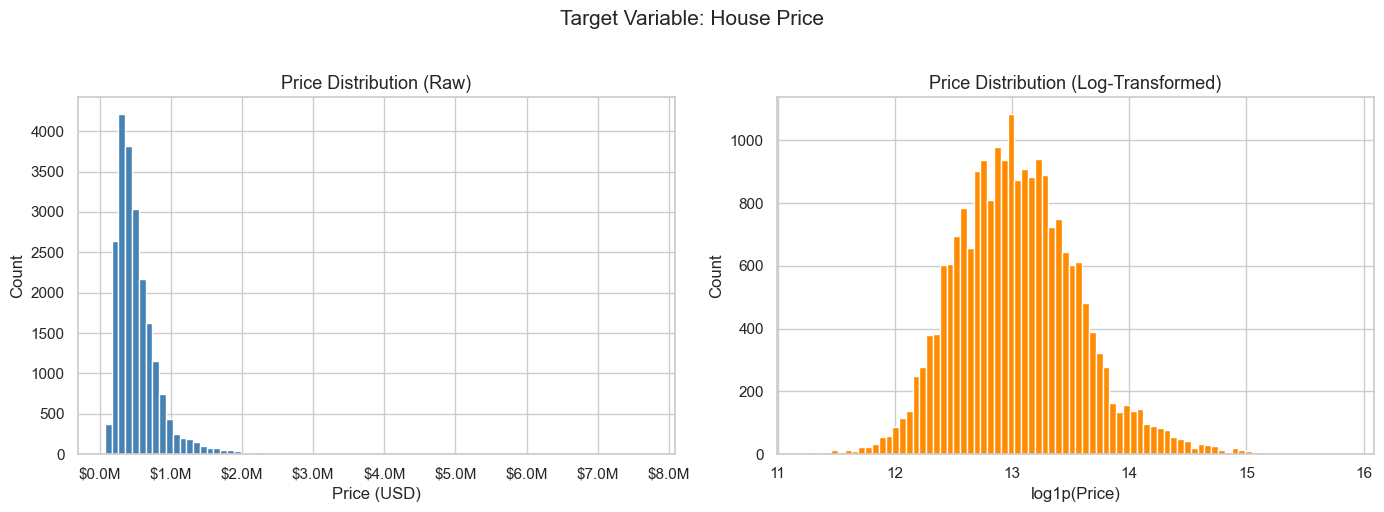

Price skewness (raw): 4.02
Price skewness (log): 0.43


In [14]:
# ── Cell 6: Price Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Log-transformed price
axes[1].hist(np.log1p(df['price']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution (Log-Transformed)', fontsize=13)
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: House Price', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f'Price skewness (raw): {df["price"].skew():.2f}')
print(f'Price skewness (log): {np.log1p(df["price"]).skew():.2f}')

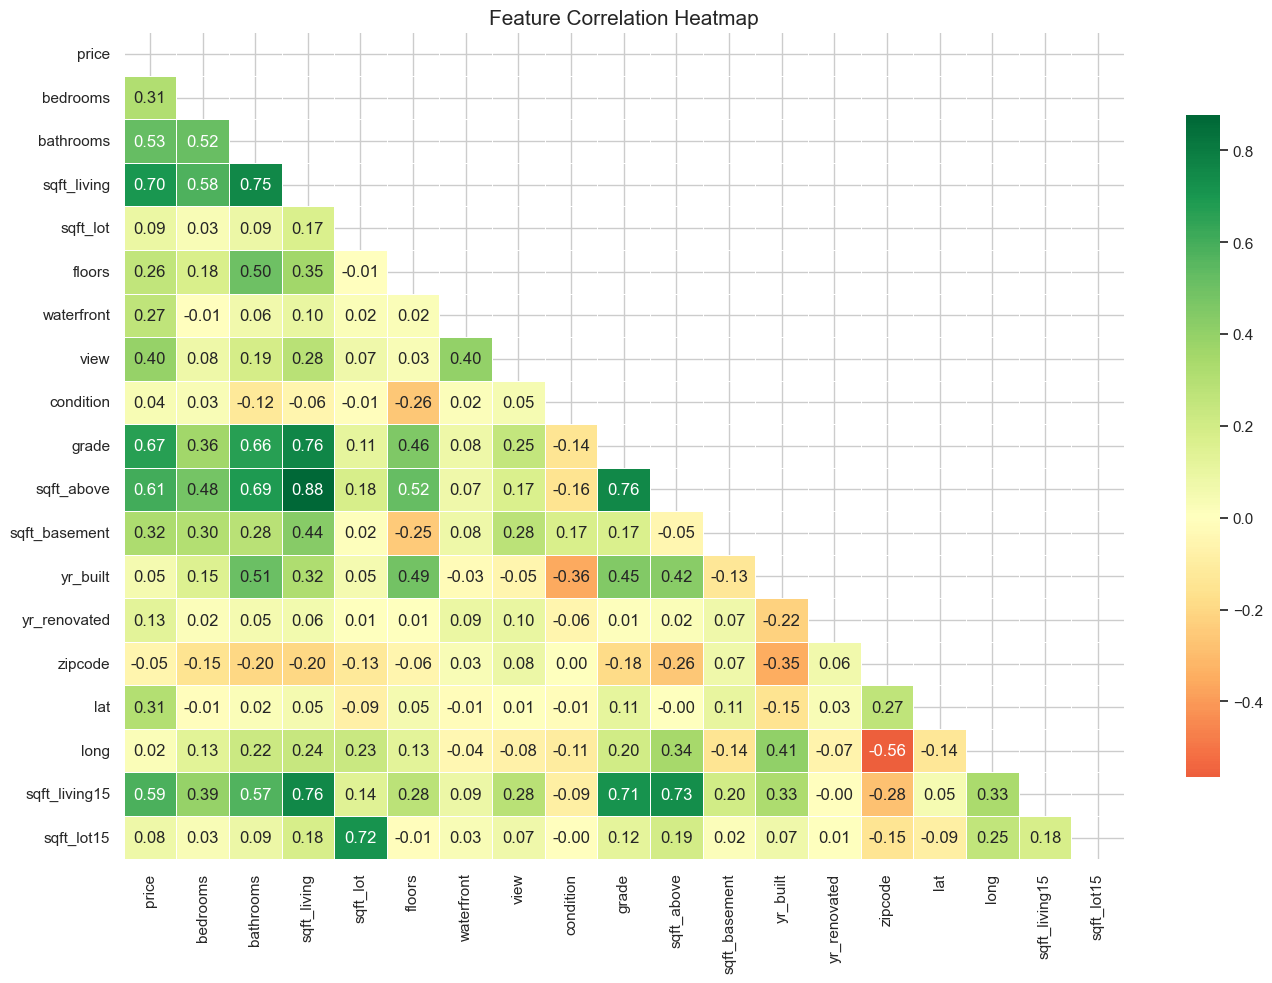


Top correlations with price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585378
bathrooms        0.525136
view             0.397294
sqft_basement    0.323816
bedrooms         0.308377
lat              0.307003
Name: price, dtype: float64


In [15]:
# ── Cell 7: Correlation Heatmap ──────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id'], errors='ignore')
corr = numeric_cols.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

print('\nTop correlations with price:')
print(corr['price'].sort_values(ascending=False).head(10))

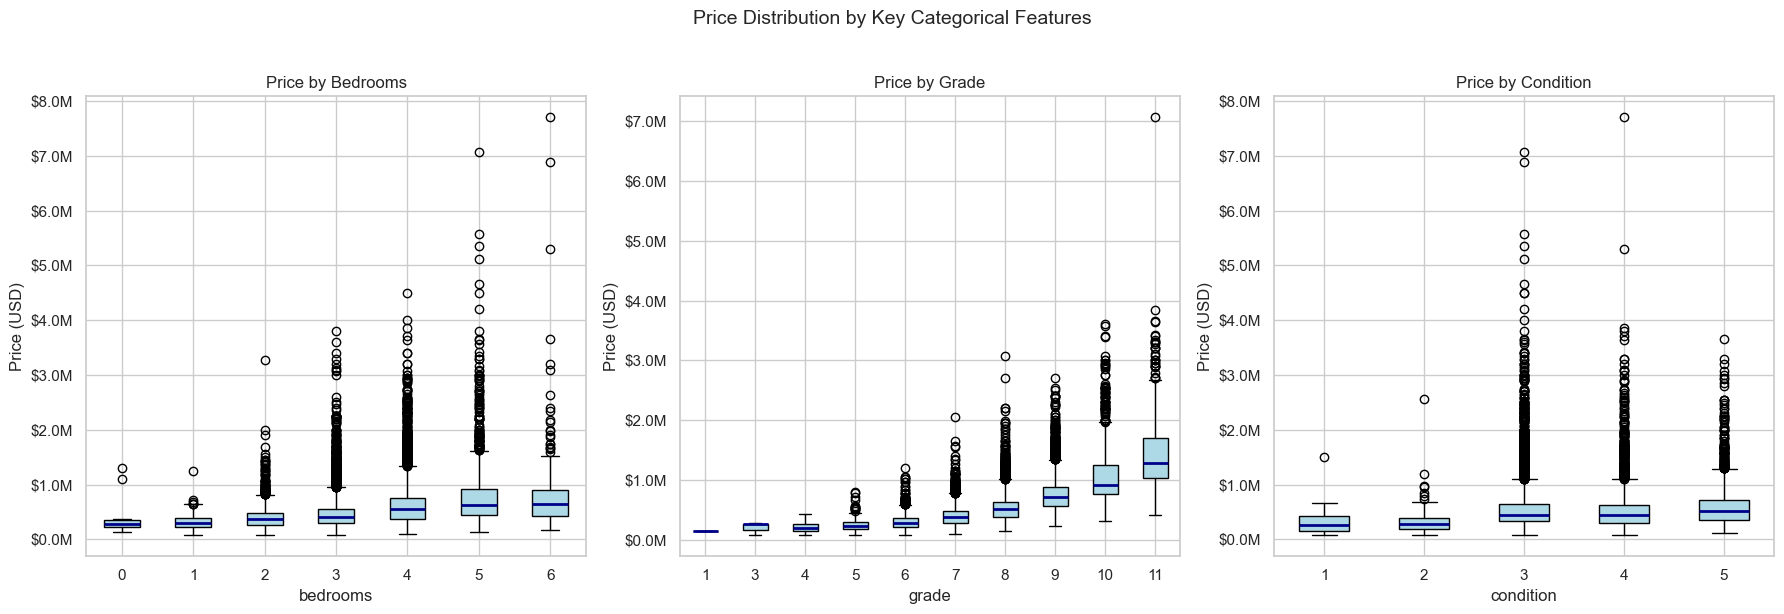

In [16]:
# ── Cell 8: Box Plots — Price vs Categorical Features ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, ['bedrooms', 'grade', 'condition']):
    temp = df[df[col] <= df[col].quantile(0.99)]  # remove extreme outliers for display
    grouped = [temp[temp[col] == v]['price'].values for v in sorted(temp[col].unique())]
    ax.boxplot(grouped, labels=sorted(temp[col].unique()), patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='darkblue', linewidth=2))
    ax.set_title(f'Price by {col.capitalize()}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Price (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Price Distribution by Key Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ── Cell 9: Scatter — sqft_living vs price ────────────────────────────────────
fig = px.scatter(
    df, x='sqft_living', y='price', color='grade',
    title='Living Area vs Price (coloured by Grade)',
    labels={'sqft_living': 'Living Area (sqft)', 'price': 'Price (USD)'},
    opacity=0.5, color_continuous_scale='Viridis', height=500
)
fig.update_layout(coloraxis_colorbar_title='Grade')
fig.show()

In [18]:
# ── Cell 10: Waterfront Premium ──────────────────────────────────────────────
wf = df.groupby('waterfront')['price'].median().reset_index()
wf['waterfront_label'] = wf['waterfront'].map({0: 'No Waterfront', 1: 'Waterfront'})

fig = px.bar(
    wf, x='waterfront_label', y='price', color='waterfront_label',
    title='Median Price: Waterfront vs Non-Waterfront',
    labels={'price': 'Median Price (USD)', 'waterfront_label': ''},
    text_auto='.2s', color_discrete_sequence=['#636EFA', '#EF553B']
)
fig.update_traces(textposition='outside')
fig.show()

In [19]:
# ── Cell 11: Geographic Scatter Map ──────────────────────────────────────────
fig = px.scatter_mapbox(
    df, lat='lat', lon='long', color='price',
    color_continuous_scale='Plasma', size_max=8,
    zoom=9, height=600,
    title='King County — House Prices by Location',
    mapbox_style='open-street-map',
    hover_data={'price': ':,.0f', 'bedrooms': True, 'sqft_living': True}
)
fig.update_layout(coloraxis_colorbar_title='Price (USD)')
fig.show()

In [20]:
# ── Cell 12: Price vs Year Built ─────────────────────────────────────────────
avg_by_year = df.groupby('yr_built')['price'].median().reset_index()

fig = px.line(
    avg_by_year, x='yr_built', y='price',
    title='Median House Price by Year Built',
    labels={'yr_built': 'Year Built', 'price': 'Median Price (USD)'}
)
fig.update_traces(line_color='steelblue')
fig.show()

In [21]:
# Cell 13a: Price per Sqft by Zipcode
df_zip = df.copy()
df_zip["price_per_sqft"] = df_zip["price"] / df_zip["sqft_living"]
zip_stats = df_zip.groupby("zipcode")["price_per_sqft"].median().sort_values(ascending=False).head(20).reset_index()
zip_stats.columns = ["zipcode", "median_price_per_sqft"]
fig = px.bar(
    zip_stats, x="zipcode", y="median_price_per_sqft",
    title="Top 20 Zipcodes by Median Price per Sqft",
    labels={"zipcode": "Zipcode", "median_price_per_sqft": "Median Price/Sqft (USD)"},
    color="median_price_per_sqft", color_continuous_scale="Reds",
    text_auto=".0f", height=480
)
fig.update_layout(xaxis_type="category", coloraxis_showscale=False)
fig.show()


In [ ]:
# Cell 13b: Violin Plot - Price by Grade
df_grade = df[df["grade"].between(4, 12)].copy()
fig = px.violin(
    df_grade, x="grade", y="price", box=True, points=False,
    title="Price Distribution by Grade (Violin Plot)",
    labels={"price": "Price (USD)", "grade": "Grade"},
    color="grade", color_discrete_sequence=px.colors.sequential.Viridis,
    height=520
)
fig.update_layout(showlegend=False)
fig.show()


In [ ]:
# Cell 13c: Pair Plot - Top 5 Correlated Features
top_features = ["sqft_living", "grade", "sqft_above", "bathrooms", "lat", "price"]
pair_df = df[top_features].sample(2000, random_state=42)
fig = px.scatter_matrix(
    pair_df,
    dimensions=["sqft_living", "grade", "sqft_above", "bathrooms", "lat"],
    color="price",
    color_continuous_scale="Plasma",
    opacity=0.4,
    title="Pair Plot - Top 5 Features coloured by Price",
    height=700
)
fig.update_traces(diagonal_visible=False, marker_size=3)
fig.show()


In [ ]:
# Cell 13d: Renovated vs Non-Renovated Price
df_reno = df.copy()
df_reno["Renovation Status"] = (df_reno["yr_renovated"] > 0).map({True: "Renovated", False: "Never Renovated"})
fig = px.box(
    df_reno, x="Renovation Status", y="price",
    color="Renovation Status",
    title="Price: Renovated vs Never Renovated",
    labels={"price": "Price (USD)"},
    color_discrete_map={"Renovated": "#2563EB", "Never Renovated": "#94A3B8"},
    points="outliers", height=480
)
med_reno    = df_reno[df_reno["yr_renovated"] > 0]["price"].median()
med_no_reno = df_reno[df_reno["yr_renovated"] == 0]["price"].median()
print(f"Median price - Renovated: ${med_reno:,.0f} | Never Renovated: ${med_no_reno:,.0f}")
print(f"Renovation premium: ${med_reno - med_no_reno:,.0f} ({(med_reno/med_no_reno - 1)*100:.1f}%)")
fig.show()


Median price - Renovated: $600,000 | Never Renovated: $448,000
Renovation premium: $152,000 (33.9%)


In [ ]:
# Cell 13e: Price Buckets Donut Chart
bins   = [0, 200_000, 500_000, 1_000_000, float("inf")]
labels = ["Under $200K", "$200K-$500K", "$500K-$1M", "Over $1M"]
df_bucket = df.copy()
df_bucket["price_bucket"] = pd.cut(df_bucket["price"], bins=bins, labels=labels)
bucket_counts = df_bucket["price_bucket"].value_counts().reset_index()
bucket_counts.columns = ["Price Range", "Count"]
fig = px.pie(
    bucket_counts, names="Price Range", values="Count",
    title="House Price Distribution by Bucket",
    hole=0.45,
    color_discrete_sequence=px.colors.sequential.Blues_r,
    height=480
)
fig.update_traces(textinfo="percent+label", pull=[0.03]*4)
fig.show()


---
## Section 3 — Feature Engineering & Preprocessing

**Engineering rationale:**
- `house_age`: captures depreciation effect  
- `renovated_flag`: binary — renovated homes command a premium  
- `basement_flag`: presence of basement as a feature  
- `sale_month`: seasonality in house prices  
- Drop `id` (identifier), parse `date` for month  
- Keep `lat`/`long` instead of `zipcode` (continuous, richer spatial signal)  
- Log-transform `price` to reduce right-skew → models trained on `y_log`

In [32]:
# ── Cell 13: Feature Engineering ─────────────────────────────────────────────
df_fe = df.copy()

# Parse date
df_fe['date'] = pd.to_datetime(df_fe['date'])
df_fe['sale_month'] = df_fe['date'].dt.month
df_fe['sale_year']  = df_fe['date'].dt.year

# Age features
df_fe['house_age']       = 2015 - df_fe['yr_built']          # dataset is 2014-2015
df_fe['renovated_flag']  = (df_fe['yr_renovated'] > 0).astype(int)
df_fe['basement_flag']   = (df_fe['sqft_basement'] > 0).astype(int)
df_fe['years_since_reno']= df_fe.apply(
    lambda r: 2015 - r['yr_renovated'] if r['yr_renovated'] > 0 else r['house_age'], axis=1
)

# Drop non-informative columns
df_fe.drop(columns=['id', 'date', 'zipcode', 'yr_built', 'yr_renovated'], inplace=True)

print('Feature-engineered shape:', df_fe.shape)
df_fe.head(3)

Feature-engineered shape: (21613, 22)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,lat,long,sqft_living15,sqft_lot15,sale_month,sale_year,house_age,renovated_flag,basement_flag,years_since_reno
0,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,...,47.5112,-122.257,1340,5650,10,2014,60,0,0,60
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,47.7210,-122.319,1690,7639,12,2014,64,1,1,24
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,47.7379,-122.233,2720,8062,2,2015,82,0,0,82


In [33]:
# ── Cell 14: Define X and y ───────────────────────────────────────────────────
TARGET = 'price'

X = df_fe.drop(columns=[TARGET])
y = np.log1p(df_fe[TARGET])   # log-transform target

FEATURE_COLUMNS = list(X.columns)
print(f'Features ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}')
print(f'Target (log-transformed): min={y.min():.2f}, max={y.max():.2f}')

Features (21): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'sale_year', 'house_age', 'renovated_flag', 'basement_flag', 'years_since_reno']
Target (log-transformed): min=11.23, max=15.86


In [34]:
# ── Cell 15: Train / Test Split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (17290, 21) | Test: (4323, 21)


In [35]:
# ── Cell 16: Scale Features ───────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler and feature columns
# MODELS_DIR was set in Cell 2 — always points next to Housing.csv
joblib.dump(scaler,          MODELS_DIR / 'scaler.pkl')
joblib.dump(FEATURE_COLUMNS, MODELS_DIR / 'feature_columns.pkl')
print('Scaler and feature columns saved ✓')
print(f'  → {MODELS_DIR}')

Scaler and feature columns saved ✓
  → /Users/kalariyatamanna/Downloads/skillsbuild-main/bob/house_price_prediction/models


### Feature Engineering Visual Validation


In [36]:
# Cell 16a: Basement vs No Basement - Price
df_fe_vis = df.copy()
df_fe_vis["Basement"] = (df_fe_vis["sqft_basement"] > 0).map({True: "Has Basement", False: "No Basement"})
fig = px.box(
    df_fe_vis, x="Basement", y="price",
    color="Basement",
    title="Price: Homes With vs Without Basement",
    labels={"price": "Price (USD)"},
    color_discrete_map={"Has Basement": "#7C3AED", "No Basement": "#94A3B8"},
    points="outliers", height=450
)
med_base   = df_fe_vis[df_fe_vis["sqft_basement"] > 0]["price"].median()
med_nobase = df_fe_vis[df_fe_vis["sqft_basement"] == 0]["price"].median()
print(f"Median price - Has Basement: ${med_base:,.0f} | No Basement: ${med_nobase:,.0f}")
print(f"Basement premium: ${med_base - med_nobase:,.0f} ({(med_base/med_nobase - 1)*100:.1f}%)")
fig.show()


Median price - Has Basement: $515,000 | No Basement: $411,500
Basement premium: $103,500 (25.2%)


In [37]:
# Cell 16b: House Age (Binned) vs Median Price
df_age = df.copy()
df_age["house_age"] = 2015 - df_age["yr_built"]
age_bins   = [0, 10, 20, 40, 60, 80, 200]
age_labels = ["0-10 yrs", "10-20 yrs", "20-40 yrs", "40-60 yrs", "60-80 yrs", "80+ yrs"]
df_age["age_group"] = pd.cut(df_age["house_age"], bins=age_bins, labels=age_labels)
age_price = df_age.groupby("age_group", observed=True)["price"].median().reset_index()
fig = px.bar(
    age_price, x="age_group", y="price",
    title="Median House Price by Age Group",
    labels={"age_group": "House Age", "price": "Median Price (USD)"},
    color="price", color_continuous_scale="Purples",
    text_auto=".2s", height=450
)
fig.update_layout(coloraxis_showscale=False)
fig.show()


---
## Section 4 — Model Training & Evaluation

In [38]:
# ── Cell 17: Train RandomForestRegressor ─────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
print('RandomForest trained ✓')

RandomForest trained ✓


In [39]:
# ── Cell 18: Train GradientBoostingRegressor ──────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(X_train_sc, y_train)
print('GradientBoosting trained ✓')

GradientBoosting trained ✓


In [40]:
# ── Cell 19: Evaluate Both Models ────────────────────────────────────────────
def evaluate_model(name, model, X_test_sc, y_test):
    y_pred_log = model.predict(X_test_sc)
    y_pred     = np.expm1(y_pred_log)   # reverse log
    y_actual   = np.expm1(y_test)
    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2   = r2_score(y_actual, y_pred)
    return {'Model': name, 'MAE ($)': f'{mae:,.0f}', 'RMSE ($)': f'{rmse:,.0f}', 'R²': f'{r2:.4f}'}

results = [
    evaluate_model('RandomForest',      rf, X_test_sc, y_test),
    evaluate_model('GradientBoosting',  gb, X_test_sc, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print('\n=== Model Comparison ===')
display(results_df)


=== Model Comparison ===


,MAE ($),RMSE ($),R²
Model,,,
RandomForest,"72,501","137,743",0.8745
GradientBoosting,"72,405","129,316",0.8894


In [41]:
# ── Cell 20: Pick Best Model ──────────────────────────────────────────────────
rf_r2 = r2_score(np.expm1(y_test), np.expm1(rf.predict(X_test_sc)))
gb_r2 = r2_score(np.expm1(y_test), np.expm1(gb.predict(X_test_sc)))

best_model      = rf if rf_r2 >= gb_r2 else gb
best_model_name = 'RandomForest' if rf_r2 >= gb_r2 else 'GradientBoosting'
print(f'Best model: {best_model_name} (R²={max(rf_r2, gb_r2):.4f})')

joblib.dump(best_model, MODELS_DIR / 'model.pkl')
joblib.dump(best_model_name, MODELS_DIR / 'model_name.pkl')
print(f'Best model saved to {MODELS_DIR}/model.pkl ✓')

Best model: GradientBoosting (R²=0.8894)
Best model saved to /Users/kalariyatamanna/Downloads/skillsbuild-main/bob/house_price_prediction/models/model.pkl ✓


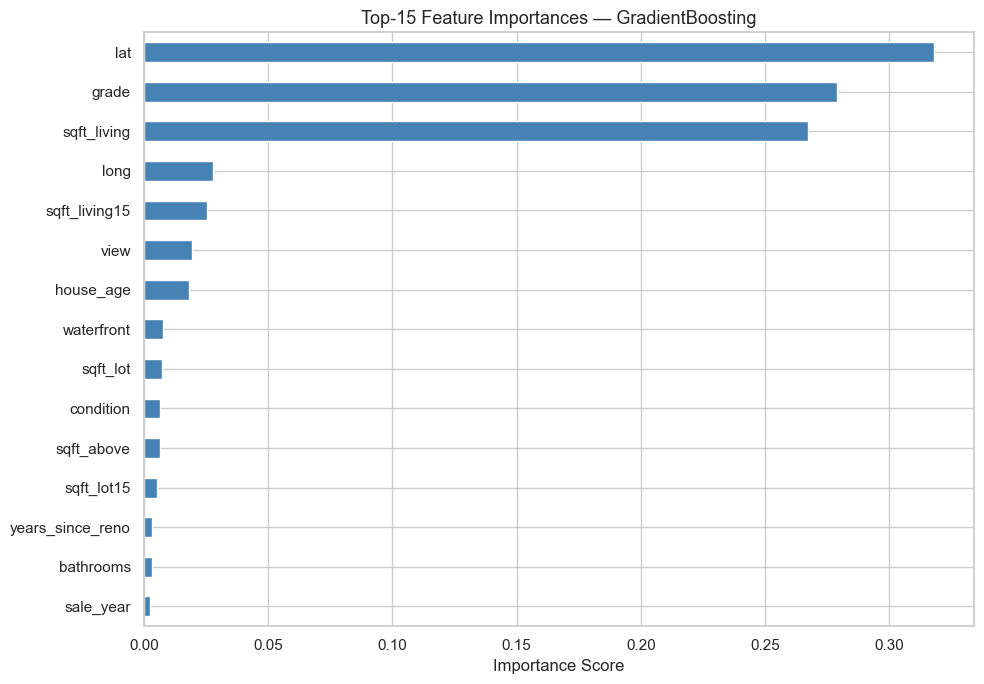

In [42]:
# ── Cell 21: Feature Importances ─────────────────────────────────────────────
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top-15 Feature Importances — {best_model_name}', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [43]:
# ── Cell 22: Actual vs Predicted ─────────────────────────────────────────────
y_pred_best = np.expm1(best_model.predict(X_test_sc))
y_actual    = np.expm1(y_test)

fig = px.scatter(
    x=y_actual, y=y_pred_best,
    labels={'x': 'Actual Price (USD)', 'y': 'Predicted Price (USD)'},
    title=f'Actual vs Predicted — {best_model_name}',
    opacity=0.4
)
# Perfect prediction reference line
line_range = [y_actual.min(), y_actual.max()]
fig.add_trace(go.Scatter(x=line_range, y=line_range, mode='lines',
                         line=dict(color='red', dash='dash'), name='Perfect Fit'))
fig.show()

In [44]:
# ── Cell 23: Residuals Distribution ──────────────────────────────────────────
residuals = y_actual - y_pred_best

fig = px.histogram(
    x=residuals, nbins=80,
    title='Residuals Distribution (Actual − Predicted)',
    labels={'x': 'Residual (USD)'},
    color_discrete_sequence=['darkorange']
)
fig.add_vline(x=0, line_dash='dash', line_color='red')
fig.show()

print(f'Mean residual: ${residuals.mean():,.0f}')
print(f'Std  residual: ${residuals.std():,.0f}')

Mean residual: $10,344
Std  residual: $128,916


### Additional Model Diagnostics


In [45]:
# Cell 24a: Learning Curve
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="neg_mean_absolute_error",
    cv=3, n_jobs=1  # single process — avoids multiprocessing pickle issues
)
train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)
lc_df = pd.DataFrame({
    "Train Size": np.concatenate([train_sizes, train_sizes]),
    "MAE (log)": np.concatenate([train_mae, val_mae]),
    "Split": ["Train"]*len(train_sizes) + ["Validation"]*len(train_sizes)
})
fig = px.line(
    lc_df, x="Train Size", y="MAE (log)", color="Split",
    markers=True,
    title=f"Learning Curve - {best_model_name}",
    labels={"Train Size": "Training Set Size", "MAE (log)": "MAE (log-scale)"},
    color_discrete_map={"Train": "steelblue", "Validation": "darkorange"},
    height=460
)
fig.show()
print("Converging train/val lines = good fit | Large gap = overfitting")


Converging train/val lines = good fit | Large gap = overfitting


In [46]:
# Cell 24b: Predicted vs Actual Distribution Overlay
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=y_actual, name="Actual Price",
    nbinsx=80, opacity=0.6, marker_color="steelblue"
))
fig.add_trace(go.Histogram(
    x=y_pred_best, name="Predicted Price",
    nbinsx=80, opacity=0.6, marker_color="darkorange"
))
fig.update_layout(
    barmode="overlay",
    title="Actual vs Predicted Price Distribution",
    xaxis_title="Price (USD)", yaxis_title="Count",
    legend=dict(x=0.75, y=0.95), height=460
)
fig.show()


In [47]:
# Cell 24c: Percentage Error Distribution
pct_error = (y_pred_best - y_actual) / y_actual * 100
fig = px.histogram(
    x=pct_error, nbins=100,
    title="Percentage Error Distribution  (Predicted - Actual) / Actual x 100",
    labels={"x": "% Error"},
    color_discrete_sequence=["mediumpurple"],
    height=460
)
fig.add_vline(x=0,   line_dash="dash", line_color="red",  annotation_text="Zero error")
fig.add_vline(x=-20, line_dash="dot",  line_color="gray", annotation_text="-20%")
fig.add_vline(x=20,  line_dash="dot",  line_color="gray", annotation_text="+20%")
fig.show()
within_10 = (pct_error.abs() <= 10).mean() * 100
within_20 = (pct_error.abs() <= 20).mean() * 100
within_30 = (pct_error.abs() <= 30).mean() * 100
print(f"Predictions within +-10%: {within_10:.1f}%")
print(f"Predictions within +-20%: {within_20:.1f}%")
print(f"Predictions within +-30%: {within_30:.1f}%")


Predictions within +-10%: 52.0%
Predictions within +-20%: 80.4%
Predictions within +-30%: 91.8%


In [48]:
# Cell 24d: SHAP Feature Importance (optional - requires: pip install shap)
try:
    import shap
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sc[:500])
    shap.summary_plot(shap_values, X_test_sc[:500],
                      feature_names=FEATURE_COLUMNS,
                      plot_type="dot", show=True)
    print("SHAP beeswarm plot shown above")
except ImportError:
    print("SHAP not installed. Run: pip install shap  then restart kernel.")
except Exception as e:
    print(f"SHAP skipped: {e}")


SHAP not installed. Run: pip install shap  then restart kernel.


In [49]:
# ── Cell 24: Save RMSE for Streamlit confidence interval ─────────────────────
rmse_val = np.sqrt(mean_squared_error(y_actual, y_pred_best))
joblib.dump(rmse_val, MODELS_DIR / 'rmse.pkl')
print(f'Test RMSE: ${rmse_val:,.0f}')
print(f'All artefacts saved to {MODELS_DIR} ✓')
print('\n=== DONE ===')

Test RMSE: $129,316
All artefacts saved to /Users/kalariyatamanna/Downloads/skillsbuild-main/bob/house_price_prediction/models ✓

=== DONE ===
